# ЦОС — ЛР №2

In [27]:
# !pip -q install numpy scipy matplotlib statsmodels pyreaper

import numpy as np
import pyreaper
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile

from scipy.signal import find_peaks
from scipy.signal.windows import triang
from statsmodels.tsa.stattools import acf as sm_acf

## 1) Загрузка WAV и нормировка


fs = 48000 Hz; duration = 18.84 s


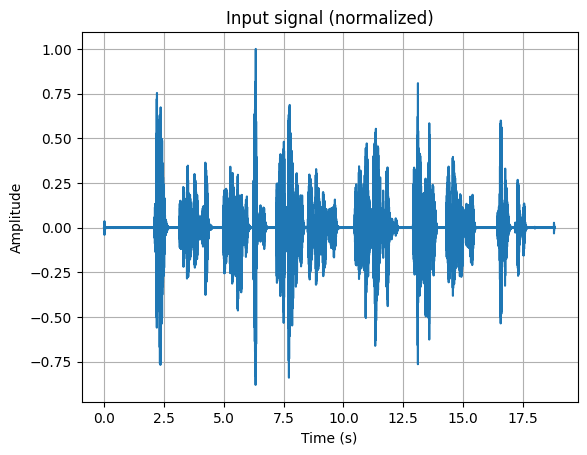

In [28]:
INPUT_WAV = "input.wav"

fs, x = wavfile.read(INPUT_WAV)
if x.ndim > 1:
    x = x[:, 0]

x = x.astype(np.float32)
x = x / np.max(np.abs(x))

t = np.arange(len(x)) / fs
print("fs =", fs, "Hz; duration =", len(x)/fs, "s")

plt.figure("Oscillogram (input)")
plt.plot(t, x)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Input signal (normalized)")
plt.grid(True)
plt.show()

## 2) АКФ и нормировка


In [29]:
def my_acf_adjusted(x: np.ndarray, m: int) -> float:
    x = np.asarray(x, dtype=np.float64)
    N = x.size
    if m < 0 or m >= N:
        raise ValueError("m must satisfy 0 <= m < N")
    mu = np.mean(x)
    a = x[:N-m] - mu
    b = x[m:] - mu
    return float(np.sum(a * b) / (N - m))


def my_acf_norm(x: np.ndarray, m: int) -> float:
    r0 = my_acf_adjusted(x, 0)
    if r0 == 0:
        return 0.0
    return my_acf_adjusted(x, m) / r0


### Проверка эквивалентности после нормировки


In [30]:
seg_len = int(0.10 * fs)
x_test = x[:seg_len]

nlags = 200
r_lib = sm_acf(x_test, nlags=nlags, adjusted=True, fft=False)
rho_lib = r_lib / r_lib[0]

ms = [0, 1, 2, 5, 10, 50, 100, 150, 200]
for m in ms:
    v_my = my_acf_norm(x_test, m)
    v_lib = float(rho_lib[m])
    print(f"m={m:4d}  my_acf={v_my:.10f}  lib={v_lib:.10f}  diff={abs(v_my-v_lib):.10f}")


m=   0  my_acf=1.0000000000  lib=1.0000000000  diff=0.0000000000
m=   1  my_acf=0.3970357193  lib=0.3970357193  diff=0.0000000000
m=   2  my_acf=-0.3967431990  lib=-0.3967431990  diff=0.0000000000
m=   5  my_acf=0.3536361565  lib=0.3536361565  diff=0.0000000000
m=  10  my_acf=-0.0808270898  lib=-0.0808270898  diff=0.0000000000
m=  50  my_acf=0.1158904186  lib=0.1158904186  diff=0.0000000000
m= 100  my_acf=0.0904406730  lib=0.0904406730  diff=0.0000000000
m= 150  my_acf=0.0666564977  lib=0.0666564977  diff=0.0000000000
m= 200  my_acf=0.0791482484  lib=0.0791482484  diff=0.0000000000


## 3) Оценка f0 по АКФ

In [31]:
def estimate_f0_acf_norm(x_seg: np.ndarray, fs: int, f_min: float = 80.0, f_max: float = 300.0):
    x_seg = np.asarray(x_seg, dtype=np.float64)
    N = len(x_seg)

    m_min = int(np.floor(fs / f_max))
    m_max = int(np.ceil(fs / f_min))
    m_max = min(m_max, N - 1)

    r = sm_acf(x_seg, nlags=m_max, adjusted=True, fft=True)
    rho = r / r[0] if r[0] != 0 else r

    rho_range = rho[m_min:m_max+1]
    peaks, _ = find_peaks(rho_range)
    if len(peaks) == 0:
        return None, rho, (m_min, m_max), None

    best_local = peaks[np.argmax(rho_range[peaks])]
    m_peak = m_min + int(best_local)
    f0 = fs / m_peak
    return float(f0), rho, (m_min, m_max), m_peak

mid = len(x)//2
half = int(0.15 * fs)
x_seg = x[max(0, mid-half): min(len(x), mid+half)]

f0_acf, rho, (m_min, m_max), m_peak = estimate_f0_acf_norm(x_seg, fs, f_min=80, f_max=300)
print("ACF(norm) f0 =", f0_acf, "Hz; m_peak =", m_peak)


ACF(norm) f0 = 98.15950920245399 Hz; m_peak = 489


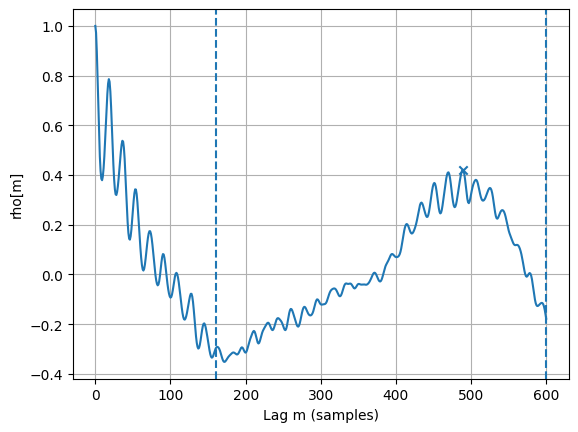

In [32]:
lags = np.arange(len(rho))
plt.figure("ACF normalized")
plt.plot(lags, rho)
plt.axvline(m_min, linestyle="--")
plt.axvline(m_max, linestyle="--")
if m_peak is not None:
    plt.scatter([m_peak], [rho[m_peak]], marker="x")
plt.xlabel("Lag m (samples)")
plt.ylabel("rho[m]")
plt.grid(True)
plt.show()


## 4) ДВПФ (my_dtft) и оценка f0

In [33]:
def my_dtft(x: np.ndarray, fs: int, f):
    x = np.asarray(x, dtype=np.float64)
    N = x.size
    n = np.arange(N)

    f_arr = np.asarray(f)
    omega = 2 * np.pi * f_arr / fs

    W = np.exp(-1j * omega[..., None] * n[None, :])
    X = np.dot(W, x)
    A = np.abs(X)

    if np.isscalar(f):
        return float(A)
    return A


def estimate_f0_dtft_max(x_seg: np.ndarray, fs: int, f_min: float = 80.0, f_max: float = 300.0, df: float = 1.0):
    x0 = np.asarray(x_seg, dtype=np.float64) - np.mean(x_seg)

    freqs = np.arange(f_min, f_max + df, df)
    A = my_dtft(x0, fs, freqs)

    idx = int(np.argmax(A))
    f0 = float(freqs[idx])
    return f0, freqs, A, idx

f0_dtft, freqs, A, idx = estimate_f0_dtft_max(x_seg, fs, f_min=80, f_max=300, df=1.0)
print("DTFT(max) f0 =", f0_dtft, "Hz")


DTFT(max) f0 = 102.0 Hz


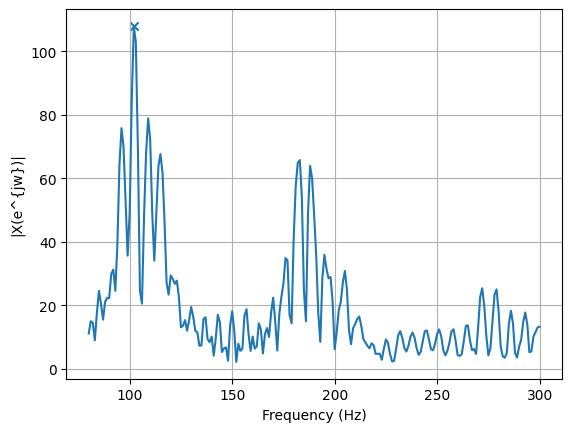

In [34]:
plt.figure("DTFT amplitude (band)")
plt.plot(freqs, A)
plt.scatter([freqs[idx]], [A[idx]], marker="x")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X(e^{jw})|")
plt.grid(True)
plt.show()


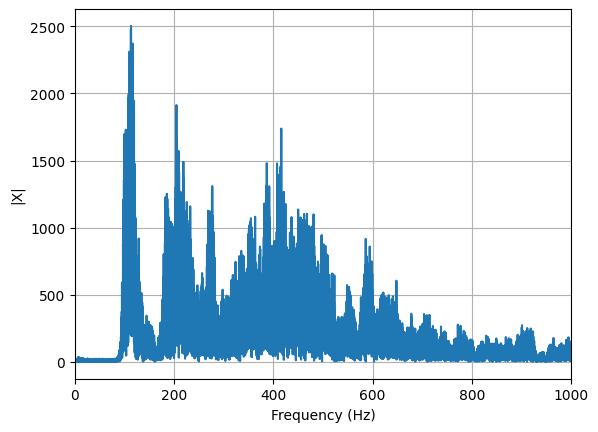

In [35]:
x0 = x.astype(np.float64) - np.mean(x)
N = len(x0)

X = np.fft.rfft(x0)
A = np.abs(X)
freqs = np.fft.rfftfreq(N, d=1/fs)

plt.figure("Spectrum of full signal (FFT)")
plt.plot(freqs, A)
plt.xlim(0, 1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X|")
plt.grid(True)
plt.show()

## 5) Google REAPER (pyreaper)


In [36]:
def reaper_pitch(x_float: np.ndarray, fs: int):
    int16_info = np.iinfo(np.int16)
    x_i16 = x_float * min(abs(int16_info.min), int16_info.max)
    x_i16 = x_i16.astype(np.int16)
    pm_times, pm, f_times, f, _ = pyreaper.reaper(x_i16, fs)
    return pm_times, pm, f_times, f

pm_times, pm, f_times, f = reaper_pitch(x, fs)
f_voiced = f[f != -1]
f0_reaper = float(np.mean(f_voiced)) if len(f_voiced) else None
print("REAPER f0 =", f0_reaper, "Hz")


REAPER f0 = 103.40194702148438 Hz


## 6) PSOLA


In [37]:
def psola_from_pm(x, fs, k, pm_samp, T, L):
    x = np.asarray(x, dtype=np.float64)
    pm_samp = np.asarray(pm_samp, dtype=int)

    w = triang(L)

    Ts = int(np.round(k * T))
    if Ts < 1:
        Ts = 1

    n_frames = len(pm_samp)
    y_len = (n_frames - 1) * Ts + L
    y = np.zeros(y_len, dtype=np.float64)

    out_pos = 0

    for m in pm_samp:
        left = m - L // 2
        right = left + L

        if left < 0 or right > len(x):
            out_pos += Ts
            continue

        frame = x[left:right] * w
        y[out_pos:out_pos + L] += frame
        out_pos += Ts

    return y

def psola(x_float: np.ndarray, fs: int, k: float):
    pm_times, pm, f_times, f = reaper_pitch(x_float, fs)

    pm_samp = (pm_times[pm == 1] * fs).astype(int)
    if len(pm_samp) < 3:
        raise RuntimeError("Not enough voiced pitch marks for PSOLA")

    d = np.diff(pm_samp)
    d = d[d > 0]
    if len(d) == 0:
        raise RuntimeError("Bad pitch marks: no positive diffs")
    T = int(np.median(d))

    L = 2 * T + 1

    y = psola_from_pm(x_float, fs, k, pm_samp, T, L)

    mx = np.max(np.abs(y))
    if mx > 0:
        y = y / mx

    return y.astype(np.float32)

k = 0.7
y = psola(x, fs, k)

OUTPUT_WAV = f"output_psola_k_{k:.2f}.wav"
wavfile.write(OUTPUT_WAV, fs, (y * 32767).astype(np.int16))
print("Saved:", OUTPUT_WAV)

Saved: output_psola_k_0.70.wav


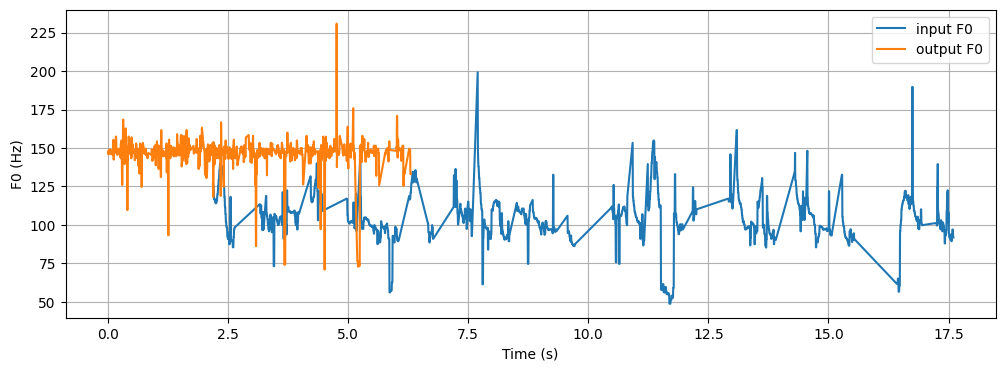

Mean F0 in : 103.40195
Mean F0 out: 145.79736
Expected ratio ~ 1/k = 1.4285714285714286
Actual ratio = 1.4100059


In [38]:
pm_t1, pm1, ft1, f1 = reaper_pitch(x, fs)
pm_t2, pm2, ft2, f2 = reaper_pitch(y, fs)

plt.figure("F0 contour (REAPER): input vs output", figsize=(12,4))
mask1 = f1 != -1
mask2 = f2 != -1
plt.plot(ft1[mask1], f1[mask1], label="input F0")
plt.plot(ft2[mask2], f2[mask2], label="output F0")
plt.xlabel("Time (s)")
plt.ylabel("F0 (Hz)")
plt.grid(True)
plt.legend()
plt.show()

f0_in = np.mean(f1[mask1]) if np.any(mask1) else None
f0_out = np.mean(f2[mask2]) if np.any(mask2) else None
print("Mean F0 in :", f0_in)
print("Mean F0 out:", f0_out)
print("Expected ratio ~ 1/k =", 1/k)
if f0_in and f0_out:
    print("Actual ratio =", f0_out / f0_in)

## 7) Таблица оценок f0


In [39]:
import pandas as pd

table = pd.DataFrame([{
    "f0_acf_norm_hz": f0_acf,
    "f0_dtft_max_hz": f0_dtft,
    "f0_reaper_avg_hz": f0_reaper
}])

table


,f0_acf_norm_hz,f0_dtft_max_hz,f0_reaper_avg_hz
0,98.159509,102.0,103.401947
